# Parent-cluster ML with explicit unvegetated endmembers and NCA keep-mask v2

This notebook reruns the preliminary supervised mapping experiment while holding the learner architecture essentially fixed and changing two support assumptions:

1. **Updated analysis mask**
   - `C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif`

2. **Explicit unvegetated endmember classes**
   - static point locations supplied in `NCA_endmembers.csv`
   - each numbered point name is treated as a replicate of its base cover class
   - e.g. `Sand 1`, `Sand 2`, ... → class `Sand`
   - only endmember points that remain inside the updated keep mask are retained
   - litter is explicitly excluded for this iteration

Vegetation labels remain the eight parent clusters from the 2016, 2018, and 2025 field-supported data.

The final random forest is applied to every annual K2 raster from 2016–2025 and writes:

- one discrete uint8 class raster
- one 3-band uncertainty raster:
  1. maximum class probability
  2. probability margin
  3. predictive entropy

Outputs are kept separate from the previous baseline:

`C:\NCA_DATA\Analysis\PrelimML_Endmembers_MaskV2`

This run is designed as a controlled comparison against the previous vegetation-only / mask-v1 baseline.


In [2]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)

# =============================================================================
# PATHS
# =============================================================================

VEG_TRAINING_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_Endmembers_MaskV2"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Search a few convenient locations for the endmember CSV.
ENDMEMBER_CANDIDATES = [
    Path(r"C:\NCA_DATA\Analysis\NCA_endmembers.csv"),
    Path(r"C:\NCA_DATA\NCA_endmembers.csv"),
    Path.cwd() / "NCA_endmembers.csv",
]

ENDMEMBER_CSV = next(
    (
        p for p in ENDMEMBER_CANDIDATES
        if p.exists()
    ),
    None,
)

if ENDMEMBER_CSV is None:
    raise FileNotFoundError(
        "Could not find NCA_endmembers.csv.\n"
        "Place it in C:\\NCA_DATA\\Analysis, C:\\NCA_DATA, "
        "or beside this notebook, or edit ENDMEMBER_CANDIDATES."
    )

VEG_YEARS = [
    2016,
    2018,
    2025,
]

YEARS_TO_MAP = list(
    range(
        2016,
        2026,
    )
)

EXPECTED_D = 45
VEG_PARENT_CODES = list(
    range(
        1,
        9,
    )
)

RANDOM_STATE = 42
N_SPLITS = 5
COMPRESS = "DEFLATE"

# We are explicitly holding litter out of this iteration.
ENDMEMBER_EXCLUDE_REGEX = r"litter"

MODEL_FOR_MAPPING = "random_forest"

print("Vegetation training:", VEG_TRAINING_CSV)
print("Endmembers:", ENDMEMBER_CSV)
print("Keep mask:", KEEP_MASK)
print("Output directory:", OUTPUT_DIR)
print("Vegetation years:", VEG_YEARS)
print("Years to map:", YEARS_TO_MAP)


Vegetation training: A:\NCA_DATA\Validation\Supervised_State_Classification\FieldVeg_K2_IA45_Training.csv
Endmembers: C:\NCA_DATA\Analysis\NCA_endmembers.csv
Keep mask: C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif
Output directory: C:\NCA_DATA\Analysis\PrelimML_Endmembers_MaskV2
Vegetation years: [2016, 2018, 2025]
Years to map: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Read and resolve the endmember classes

The uploaded CSV contains 221 uniquely named point locations with fields:

- `name`
- `EASTING`
- `NORTHING`

The numbered suffix identifies replicate locations. The base text is the mapping class:

`Bright Cliff 17` → `Bright Cliff`

This produces candidate endmember classes such as `Sand`, `Playa`, `Dark Cliff`, `Bright Cliff`, etc.


In [3]:
# =============================================================================
# ENDMEMBER CLASS RESOLUTION
# =============================================================================

end_raw = pd.read_csv(
    ENDMEMBER_CSV,
    low_memory=False,
)

required_end = {
    "name",
    "EASTING",
    "NORTHING",
}

missing = required_end - set(
    end_raw.columns
)

if missing:
    raise KeyError(
        f"Endmember CSV missing columns: {sorted(missing)}"
    )

end_raw["name"] = (
    end_raw["name"]
    .astype(str)
    .str.strip()
)

end_raw["EASTING"] = pd.to_numeric(
    end_raw["EASTING"],
    errors="coerce",
)

end_raw["NORTHING"] = pd.to_numeric(
    end_raw["NORTHING"],
    errors="coerce",
)

if end_raw[
    [
        "EASTING",
        "NORTHING",
    ]
].isna().any().any():

    raise ValueError(
        "Endmember CSV contains missing/non-numeric coordinates."
    )

# Strip the final integer sample number only.
end_raw[
    "endmember_class"
] = (
    end_raw["name"]
    .str.replace(
        r"\s+\d+$",
        "",
        regex=True,
    )
    .str.strip()
)

# Explicitly omit litter from this iteration.
exclude_litter = (
    end_raw[
        "endmember_class"
    ]
    .str.contains(
        ENDMEMBER_EXCLUDE_REGEX,
        case=False,
        regex=True,
        na=False,
    )
)

if exclude_litter.any():

    print(
        "Excluding litter points:",
        int(
            exclude_litter.sum()
        )
    )

    end_raw = (
        end_raw.loc[
            ~exclude_litter
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

print(
    "Candidate endmember points:",
    f"{len(end_raw):,}"
)

print(
    "Candidate endmember classes:",
    end_raw[
        "endmember_class"
    ].nunique()
)

display(
    end_raw[
        "endmember_class"
    ]
    .value_counts()
    .rename_axis(
        "endmember_class"
    )
    .reset_index(
        name="n_points"
    )
)


Candidate endmember points: 221
Candidate endmember classes: 12


,endmember_class,n_points
0,Building,34
1,Dark Cliff,31
2,Sand,30
3,Bright Cliff,29
4,Solar,20
5,Water,20
6,Playa,19
7,Road,14
8,Pavement,12
9,BG/Parking Lot,7


## 2. Filter endmember locations through the updated mask

An endmember point is retained only if its exact point location falls on a positive keep-mask pixel.

The audit table preserves both kept and removed candidates.


In [4]:
# =============================================================================
# MASK-SAMPLE POINTS
# =============================================================================

if not KEEP_MASK.exists():
    raise FileNotFoundError(
        f"Updated keep mask not found:\n{KEEP_MASK}"
    )


def mask_keep_for_points(
    table,
    x_col,
    y_col,
    mask_path,
):

    keep_flags = []
    mask_values = []

    with rasterio.open(
        mask_path
    ) as src:

        print(
            "Mask CRS:",
            src.crs
        )

        print(
            "Mask bounds:",
            src.bounds
        )

        nodata = src.nodata

        for x, y in zip(
            table[x_col].to_numpy(),
            table[y_col].to_numpy(),
        ):

            inside = (
                src.bounds.left <= x <= src.bounds.right
                and src.bounds.bottom <= y <= src.bounds.top
            )

            if not inside:

                mask_values.append(
                    np.nan
                )

                keep_flags.append(
                    False
                )

                continue

            value = next(
                src.sample(
                    [
                        (
                            float(x),
                            float(y),
                        )
                    ],
                    indexes=1,
                    masked=False,
                )
            )[0]

            valid = np.isfinite(
                value
            )

            if (
                nodata is not None
                and np.isfinite(
                    nodata
                )
            ):

                valid &= not np.isclose(
                    value,
                    nodata,
                )

            keep = (
                valid
                and value > 0
            )

            mask_values.append(
                float(value)
                if np.isfinite(
                    value
                )
                else np.nan
            )

            keep_flags.append(
                bool(
                    keep
                )
            )

    out = table.copy()

    out[
        "mask_value"
    ] = mask_values

    out[
        "keep_v2"
    ] = keep_flags

    return out


end_audit = mask_keep_for_points(
    table=end_raw,
    x_col="EASTING",
    y_col="NORTHING",
    mask_path=KEEP_MASK,
)

end_audit.to_csv(
    OUTPUT_DIR
    / "NCA_endmembers_maskV2_audit.csv",
    index=False,
)

end_keep = (
    end_audit.loc[
        end_audit[
            "keep_v2"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Candidate points:",
    f"{len(end_audit):,}"
)

print(
    "Retained by mask:",
    f"{len(end_keep):,}"
)

print(
    "Removed by mask:",
    f"{(~end_audit['keep_v2']).sum():,}"
)

survival = (
    end_audit.groupby(
        "endmember_class",
        as_index=False,
    )
    .agg(
        n_candidate=(
            "name",
            "size",
        ),
        n_retained=(
            "keep_v2",
            "sum",
        ),
    )
)

survival[
    "retained_fraction"
] = (
    survival[
        "n_retained"
    ]
    / survival[
        "n_candidate"
    ]
)

display(
    survival.sort_values(
        [
            "n_retained",
            "endmember_class",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

surviving_classes = sorted(
    end_keep[
        "endmember_class"
    ]
    .unique()
    .tolist()
)

print(
    "\nSurviving endmember classes:"
)

for cls in surviving_classes:
    print(
        " ",
        cls
    )


if len(
    surviving_classes
) == 0:

    raise RuntimeError(
        "No endmember points survive the updated keep mask."
    )


Mask CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Mask bounds: BoundingBox(left=527740.0, bottom=4736840.0, right=632090.0, top=4815410.0)
Candidate points: 221
Retained by mask: 137
Removed by mask: 84


,endmember_class,n_candidate,n_retained,retained_fraction
5,Dark Cliff,31,31,1.000000
9,Sand,30,30,1.000000
2,Bright Cliff,29,26,0.896552
7,Playa,19,18,0.947368
6,Pavement,12,11,0.916667
1,BG/Parking Lot,7,7,1.000000
3,Building,34,7,0.205882
8,Road,14,7,0.500000
0,Asphalt,2,0,0.000000
4,Cow,3,0,0.000000



Surviving endmember classes:
  BG/Parking Lot
  Bright Cliff
  Building
  Dark Cliff
  Pavement
  Playa
  Road
  Sand


## 3. Load the vegetation training set and apply mask-v2 support

The original vegetation IA45 table is retained as the source of the eight parent labels. Where coordinates are available, vegetation observations are also checked against the updated keep mask so that the classifier is trained on the same support being mapped.


In [5]:
# =============================================================================
# VEGETATION TRAINING DATA
# =============================================================================

if not VEG_TRAINING_CSV.exists():
    raise FileNotFoundError(
        f"Vegetation training CSV not found:\n{VEG_TRAINING_CSV}"
    )

veg = pd.read_csv(
    VEG_TRAINING_CSV,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)

required_veg = {
    "PlotID",
    "Year",
    "parent_cluster",
}

missing = (
    required_veg
    - set(
        veg.columns
    )
)

if missing:
    raise KeyError(
        f"Vegetation training data missing columns: {sorted(missing)}"
    )

veg["Year"] = pd.to_numeric(
    veg["Year"],
    errors="coerce",
)

veg[
    "parent_cluster"
] = pd.to_numeric(
    veg[
        "parent_cluster"
    ],
    errors="coerce",
)

veg = (
    veg.loc[
        veg["Year"].isin(
            VEG_YEARS
        )
        & veg[
            "parent_cluster"
        ].notna()
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

veg["Year"] = veg["Year"].astype(
    int
)

veg[
    "parent_cluster"
] = veg[
    "parent_cluster"
].astype(
    int
)

veg["PlotID"] = (
    veg["PlotID"]
    .astype(str)
    .str.strip()
)

# Apply mask-v2 to vegetation rows if coordinates are present.
coord_cols = (
    "Easting",
    "Northing",
)

if all(
    c in veg.columns
    for c in coord_cols
):

    veg[
        "Easting"
    ] = pd.to_numeric(
        veg[
            "Easting"
        ],
        errors="coerce",
    )

    veg[
        "Northing"
    ] = pd.to_numeric(
        veg[
            "Northing"
        ],
        errors="coerce",
    )

    coord_ok = veg[
        [
            "Easting",
            "Northing",
        ]
    ].notna().all(
        axis=1
    )

    if not coord_ok.all():

        warnings.warn(
            f"{int((~coord_ok).sum())} vegetation rows lack coordinates; "
            "they will be removed for mask-v2 consistency."
        )

    veg_coord = (
        veg.loc[
            coord_ok
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    veg_audit = mask_keep_for_points(
        table=veg_coord,
        x_col="Easting",
        y_col="Northing",
        mask_path=KEEP_MASK,
    )

    veg_audit.to_csv(
        OUTPUT_DIR
        / "vegetation_training_maskV2_audit.csv",
        index=False,
    )

    veg = (
        veg_audit.loc[
            veg_audit[
                "keep_v2"
            ]
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

else:

    warnings.warn(
        "Vegetation training table does not contain Easting/Northing. "
        "Vegetation rows cannot be mask-filtered and will be retained."
    )

print(
    "Vegetation observations retained:",
    f"{len(veg):,}"
)

display(
    veg.groupby(
        [
            "Year",
            "parent_cluster",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n",
        }
    )
)


Mask CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Mask bounds: BoundingBox(left=527740.0, bottom=4736840.0, right=632090.0, top=4815410.0)
Vegetation observations retained: 467


,Year,parent_cluster,n
0,2016,1,39
1,2016,2,28
2,2016,3,37
3,2016,4,43
4,2016,5,46
5,2016,6,23
6,2016,7,18
7,2016,8,10
8,2018,1,11
9,2018,2,17


## 4. Resolve IA45 and annual raster-band matching


In [6]:
# =============================================================================
# IA45 + BAND MATCHING
# =============================================================================

intercept_cols = [
    c for c in veg.columns
    if re.search(
        r"^(constant_|intercept_)",
        str(c),
        flags=re.IGNORECASE,
    )
]

amplitude_cols = [
    c for c in veg.columns
    if re.search(
        r"^(amp|amplitude)",
        str(c),
        flags=re.IGNORECASE,
    )
]

IA_COLS = (
    intercept_cols
    + amplitude_cols
)

if len(
    IA_COLS
) != EXPECTED_D:

    raise ValueError(
        f"Expected {EXPECTED_D} IA predictors; "
        f"found {len(IA_COLS)}."
    )

print(
    "IA dimensions:",
    len(
        IA_COLS
    )
)


def annual_k2_path(
    year,
):

    return (
        HARMONIC_ROOT
        / str(
            year
        )
        / (
            f"{year}"
            "_K2_InterceptAmpPhase_nobs_RMSE.tif"
        )
    )


def get_band_names(
    src,
):

    return [
        (
            str(
                desc
            ).strip()
            if desc is not None
            and str(
                desc
            ).strip()
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def normalize_name(
    x,
):

    return (
        str(
            x
        )
        .strip()
        .lower()
    )


def ia_band_indexes(
    src,
    ia_cols,
):

    names = get_band_names(
        src
    )

    lookup = {
        normalize_name(
            name
        ): i
        for i, name in enumerate(
            names,
            start=1,
        )
    }

    indexes = []
    missing = []

    for feature in ia_cols:

        key = normalize_name(
            feature
        )

        if key not in lookup:

            missing.append(
                feature
            )

        else:

            indexes.append(
                lookup[
                    key
                ]
            )

    if missing:

        raise KeyError(
            "Missing IA45 raster bands:\n"
            + "\n".join(
                missing
            )
        )

    return indexes


for year in YEARS_TO_MAP:

    path = annual_k2_path(
        year
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Missing annual K2 raster:\n{path}"
        )

    with rasterio.open(
        path
    ) as src:

        idx = ia_band_indexes(
            src,
            IA_COLS,
        )

        if len(
            idx
        ) != EXPECTED_D:

            raise RuntimeError(
                f"{year}: expected {EXPECTED_D} IA bands; "
                f"matched {len(idx)}."
            )

        print(
            year,
            "| IA bands:",
            len(
                idx
            ),
        )


IA dimensions: 45
2016 | IA bands: 45
2017 | IA bands: 45
2018 | IA bands: 45
2019 | IA bands: 45
2020 | IA bands: 45
2021 | IA bands: 45
2022 | IA bands: 45
2023 | IA bands: 45
2024 | IA bands: 45
2025 | IA bands: 45


## 5. Extract every surviving static endmember location through 2016–2025

Each retained endmember location contributes one annual IA45 observation wherever the annual harmonic raster is valid.

The physical location is the grouped-CV unit, so the same endmember site cannot leak between training and test folds through repeated years.


In [7]:
# =============================================================================
# EXTRACT ENDMEMBER IA45 THROUGH TIME
# =============================================================================

endmember_rows = []

xy = list(
    zip(
        end_keep[
            "EASTING"
        ].astype(
            float
        ),
        end_keep[
            "NORTHING"
        ].astype(
            float
        ),
    )
)

for year in YEARS_TO_MAP:

    path = annual_k2_path(
        year
    )

    with rasterio.open(
        path
    ) as src:

        indexes = ia_band_indexes(
            src,
            IA_COLS,
        )

        sampled = np.asarray(
            list(
                src.sample(
                    xy,
                    indexes=indexes,
                    masked=False,
                )
            ),
            dtype=np.float32,
        )

        if sampled.shape != (
            len(
                end_keep
            ),
            EXPECTED_D,
        ):

            raise RuntimeError(
                f"{year}: unexpected endmember extraction shape "
                f"{sampled.shape}."
            )

        valid = np.isfinite(
            sampled
        ).all(
            axis=1
        )

        if src.nodata is not None:

            valid &= ~np.any(
                np.isclose(
                    sampled,
                    src.nodata,
                ),
                axis=1,
            )

        print(
            year,
            "| valid endmember points:",
            f"{int(valid.sum()):,}",
            "/",
            f"{len(end_keep):,}",
        )

        for row_i in np.where(
            valid
        )[0]:

            base = {
                "sample_source": "endmember",
                "sample_id": str(
                    end_keep.loc[
                        row_i,
                        "name",
                    ]
                ),
                "sample_group": (
                    "END::"
                    + str(
                        end_keep.loc[
                            row_i,
                            "name",
                        ]
                    )
                ),
                "Year": int(
                    year
                ),
                "class_name": (
                    "END::"
                    + str(
                        end_keep.loc[
                            row_i,
                            "endmember_class",
                        ]
                    )
                ),
                "endmember_class": str(
                    end_keep.loc[
                        row_i,
                        "endmember_class",
                    ]
                ),
                "Easting": float(
                    end_keep.loc[
                        row_i,
                        "EASTING",
                    ]
                ),
                "Northing": float(
                    end_keep.loc[
                        row_i,
                        "NORTHING",
                    ]
                ),
            }

            for j, feature in enumerate(
                IA_COLS
            ):

                base[
                    feature
                ] = float(
                    sampled[
                        row_i,
                        j,
                    ]
                )

            endmember_rows.append(
                base
            )


end_samples = pd.DataFrame(
    endmember_rows
)

if len(
    end_samples
) == 0:

    raise RuntimeError(
        "No valid annual endmember samples were extracted."
    )

end_samples.to_csv(
    OUTPUT_DIR
    / "NCA_endmembers_IA45_2016_2025_maskV2.csv",
    index=False,
)

print(
    "\nAnnual endmember observations:",
    f"{len(end_samples):,}"
)

display(
    end_samples.groupby(
        [
            "class_name",
        ],
        as_index=False,
    )
    .agg(
        n_observations=(
            "sample_id",
            "size",
        ),
        n_unique_locations=(
            "sample_id",
            "nunique",
        ),
        n_years=(
            "Year",
            "nunique",
        ),
    )
    .sort_values(
        "class_name"
    )
)


2016 | valid endmember points: 88 / 137
2017 | valid endmember points: 95 / 137
2018 | valid endmember points: 92 / 137
2019 | valid endmember points: 93 / 137
2020 | valid endmember points: 97 / 137
2021 | valid endmember points: 98 / 137
2022 | valid endmember points: 90 / 137
2023 | valid endmember points: 93 / 137
2024 | valid endmember points: 91 / 137
2025 | valid endmember points: 83 / 137

Annual endmember observations: 920


,class_name,n_observations,n_unique_locations,n_years
0,END::BG/Parking Lot,53,7,10
1,END::Bright Cliff,49,11,10
2,END::Building,69,7,10
3,END::Dark Cliff,310,31,10
4,END::Pavement,74,11,10
5,END::Playa,6,1,6
6,END::Road,64,7,10
7,END::Sand,295,30,10


## 6. Assemble vegetation + endmember training data

The final response space is:

- `VEG::1` ... `VEG::8`
- one class per surviving unvegetated cover type

`class_weight="balanced"` / `"balanced_subsample"` is retained so the annual replication of endmember sites does not simply overwhelm the vegetation classes numerically.


In [8]:
# =============================================================================
# COMBINED TRAINING TABLE
# =============================================================================

# Validate vegetation IA45.
veg_X = (
    veg[
        IA_COLS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
)

bad_veg = veg_X.isna().any(
    axis=1
)

if bad_veg.any():

    raise ValueError(
        f"{int(bad_veg.sum()):,} retained vegetation rows "
        "contain incomplete IA45."
    )


veg_samples = pd.DataFrame({
    "sample_source": "vegetation",
    "sample_id": veg[
        "PlotID"
    ].astype(
        str
    ),
    "sample_group": (
        "VEG::"
        + veg[
            "PlotID"
        ].astype(
            str
        )
    ),
    "Year": veg[
        "Year"
    ].astype(
        int
    ),
    "class_name": (
        "VEG::"
        + veg[
            "parent_cluster"
        ].astype(
            int
        ).astype(
            str
        )
    ),
    "parent_cluster": veg[
        "parent_cluster"
    ].astype(
        int
    ),
})

for feature in IA_COLS:

    veg_samples[
        feature
    ] = pd.to_numeric(
        veg[
            feature
        ],
        errors="raise",
    ).astype(
        float
    )


combined = pd.concat(
    [
        veg_samples,
        end_samples,
    ],
    ignore_index=True,
    sort=False,
)

VEG_CLASSES = [
    f"VEG::{i}"
    for i in VEG_PARENT_CODES
]

END_CLASSES = sorted(
    end_samples[
        "class_name"
    ].unique().tolist()
)

ALL_CLASSES = (
    VEG_CLASSES
    + END_CLASSES
)

# Integer codes for raster output.
CLASS_TO_CODE = {
    class_name: i
    for i, class_name in enumerate(
        ALL_CLASSES,
        start=1,
    )
}

CODE_TO_CLASS = {
    code: name
    for name, code in CLASS_TO_CODE.items()
}

class_lookup = pd.DataFrame({
    "class_code": [
        CLASS_TO_CODE[
            c
        ]
        for c in ALL_CLASSES
    ],
    "class_name": ALL_CLASSES,
    "class_source": [
        (
            "vegetation"
            if c.startswith(
                "VEG::"
            )
            else "endmember"
        )
        for c in ALL_CLASSES
    ],
})

class_lookup[
    "display_name"
] = (
    class_lookup[
        "class_name"
    ]
    .str.replace(
        "VEG::",
        "Parent ",
        regex=False,
    )
    .str.replace(
        "END::",
        "",
        regex=False,
    )
)

class_lookup.to_csv(
    OUTPUT_DIR
    / "ParentML_class_lookup.csv",
    index=False,
)

combined.to_csv(
    OUTPUT_DIR
    / "ParentML_combined_training_maskV2_endmembers.csv",
    index=False,
)

print(
    "Combined training observations:",
    f"{len(combined):,}"
)

print(
    "Total classes:",
    len(
        ALL_CLASSES
    )
)

print(
    "Vegetation classes:",
    len(
        VEG_CLASSES
    )
)

print(
    "Endmember classes:",
    len(
        END_CLASSES
    )
)

display(
    class_lookup
)

display(
    combined.groupby(
        [
            "sample_source",
            "class_name",
        ],
        as_index=False,
    )
    .agg(
        n=(
            "sample_id",
            "size",
        ),
        unique_groups=(
            "sample_group",
            "nunique",
        ),
    )
)


Combined training observations: 1,387
Total classes: 16
Vegetation classes: 8
Endmember classes: 8


,class_code,class_name,class_source,display_name
0,1,VEG::1,vegetation,Parent 1
1,2,VEG::2,vegetation,Parent 2
2,3,VEG::3,vegetation,Parent 3
3,4,VEG::4,vegetation,Parent 4
4,5,VEG::5,vegetation,Parent 5
5,6,VEG::6,vegetation,Parent 6
6,7,VEG::7,vegetation,Parent 7
7,8,VEG::8,vegetation,Parent 8
8,9,END::BG/Parking Lot,endmember,BG/Parking Lot
9,10,END::Bright Cliff,endmember,Bright Cliff


,sample_source,class_name,n,unique_groups
0,endmember,END::BG/Parking Lot,53,7
1,endmember,END::Bright Cliff,49,11
2,endmember,END::Building,69,7
3,endmember,END::Dark Cliff,310,31
4,endmember,END::Pavement,74,11
5,endmember,END::Playa,6,1
6,endmember,END::Road,64,7
7,endmember,END::Sand,295,30
8,vegetation,VEG::1,80,80
9,vegetation,VEG::2,59,59


## 7. Group-support diagnostic

Endmember classes with very few unique physical locations are retained, because they are part of the requested mapping label space, but they are flagged as provisional.

Grouped out-of-fold validation is intentionally strict: all annual observations from the same endmember location stay together.


In [9]:
# =============================================================================
# CLASS SUPPORT
# =============================================================================

support = (
    combined.groupby(
        "class_name",
        as_index=False,
    )
    .agg(
        n_observations=(
            "sample_id",
            "size",
        ),
        n_groups=(
            "sample_group",
            "nunique",
        ),
        n_years=(
            "Year",
            "nunique",
        ),
    )
)

support[
    "low_spatial_support"
] = (
    support[
        "n_groups"
    ] < N_SPLITS
)

display(
    support.sort_values(
        [
            "low_spatial_support",
            "n_groups",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

low = support.loc[
    support[
        "low_spatial_support"
    ]
]

if len(
    low
) > 0:

    warnings.warn(
        "Some classes have fewer unique physical groups than CV folds. "
        "Their OOF class metrics will be intentionally harsh / unstable. "
        "They are still retained in the final mapping model."
    )


,class_name,n_observations,n_groups,n_years,low_spatial_support
5,END::Playa,6,1,6,True
0,END::BG/Parking Lot,53,7,10,False
2,END::Building,69,7,10,False
6,END::Road,64,7,10,False
1,END::Bright Cliff,49,11,10,False
4,END::Pavement,74,11,10,False
15,VEG::8,19,19,3,False
7,END::Sand,295,30,10,False
14,VEG::7,30,30,3,False
3,END::Dark Cliff,310,31,10,False


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_35760\731879441.py:57: UserWarning: Some classes have fewer unique physical groups than CV folds. Their OOF class metrics will be intentionally harsh / unstable. They are still retained in the final mapping model.
  warnings.warn(


## 8. Candidate classifiers

To isolate the effect of the new mask/endmembers, the same three preliminary learners are retained.

The final maps default to the random forest so comparison with the original baseline remains controlled.


In [10]:
# =============================================================================
# MODEL MATRIX
# =============================================================================

MODELS = {
    "elastic_net_logistic": Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                l1_ratio=0.5,
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "random_forest": RandomForestClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

if MODEL_FOR_MAPPING not in MODELS:

    raise KeyError(
        f"Unknown MODEL_FOR_MAPPING: {MODEL_FOR_MAPPING}"
    )

X = (
    combined[
        IA_COLS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

y = (
    combined[
        "class_name"
    ]
    .astype(
        str
    )
    .to_numpy()
)

groups = (
    combined[
        "sample_group"
    ]
    .astype(
        str
    )
    .to_numpy()
)

print(
    "X:",
    X.shape
)

print(
    "Classes:",
    len(
        np.unique(
            y
        )
    )
)

print(
    "Physical groups:",
    pd.Series(
        groups
    ).nunique()
)


X: (1387, 45)
Classes: 16
Physical groups: 531


## 9. Evaluation helpers

Two metric families are reported:

1. **all-class metrics** over vegetation + endmembers
2. **vegetation-only metrics** on rows whose true label is one of the eight vegetation parents

The second is the most direct comparison to the original 8-parent baseline.


In [11]:
# =============================================================================
# METRICS
# =============================================================================

def align_probabilities(
    proba,
    model_classes,
    target_classes,
):

    out = np.zeros(
        (
            len(
                proba
            ),
            len(
                target_classes
            ),
        ),
        dtype=np.float32,
    )

    lookup = {
        str(
            cls
        ): j
        for j, cls in enumerate(
            model_classes
        )
    }

    for j, cls in enumerate(
        target_classes
    ):

        if cls in lookup:

            out[
                :,
                j,
            ] = proba[
                :,
                lookup[
                    cls
                ],
            ]

    sums = out.sum(
        axis=1,
        keepdims=True,
    )

    valid = (
        sums[
            :,
            0
        ] > 0
    )

    out[
        valid
    ] /= sums[
        valid
    ]

    return out


def score_label_predictions(
    y_true,
    y_pred,
    labels,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0,
        ),
    }


def score_vegetation_subset(
    y_true,
    y_pred,
):

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    mask = np.isin(
        y_true,
        VEG_CLASSES,
    )

    return {
        "veg_n": int(
            mask.sum()
        ),
        "veg_accuracy": accuracy_score(
            y_true[
                mask
            ],
            y_pred[
                mask
            ],
        ),
        "veg_balanced_accuracy": balanced_accuracy_score(
            y_true[
                mask
            ],
            y_pred[
                mask
            ],
        ),
        "veg_macro_f1": f1_score(
            y_true[
                mask
            ],
            y_pred[
                mask
            ],
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
        "veg_predicted_as_endmember_fraction": float(
            np.mean(
                np.char.startswith(
                    y_pred[
                        mask
                    ].astype(
                        str
                    ),
                    "END::",
                )
            )
        ),
    }


## 10. Five-fold stratified grouped OOF validation

Grouping prevents temporal replicates of the same PlotID/endmember location from leaking across train/test folds.


In [12]:
# =============================================================================
# GROUPED OOF
# =============================================================================

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []
oof = {}

for model_name, template in MODELS.items():

    pred_all = np.empty(
        len(
            combined
        ),
        dtype=object,
    )

    pred_all[:] = None

    for fold, (
        train_idx,
        test_idx,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups,
        ),
        start=1,
    ):

        fitted = clone(
            template
        )

        fitted.fit(
            X[
                train_idx
            ],
            y[
                train_idx
            ],
        )

        pred = fitted.predict(
            X[
                test_idx
            ]
        ).astype(
            str
        )

        pred_all[
            test_idx
        ] = pred

        all_scores = score_label_predictions(
            y_true=y[
                test_idx
            ],
            y_pred=pred,
            labels=ALL_CLASSES,
        )

        veg_scores = score_vegetation_subset(
            y_true=y[
                test_idx
            ],
            y_pred=pred,
        )

        cv_rows.append({
            "model": model_name,
            "fold": fold,
            "n_train": len(
                train_idx
            ),
            "n_test": len(
                test_idx
            ),
            **all_scores,
            **veg_scores,
        })

    oof[
        model_name
    ] = pred_all


cv_results = pd.DataFrame(
    cv_rows
)

cv_summary = (
    cv_results.groupby(
        "model",
        as_index=False,
    )
    .agg(
        all_accuracy_mean=(
            "accuracy",
            "mean",
        ),
        all_macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        veg_accuracy_mean=(
            "veg_accuracy",
            "mean",
        ),
        veg_balanced_accuracy_mean=(
            "veg_balanced_accuracy",
            "mean",
        ),
        veg_macro_f1_mean=(
            "veg_macro_f1",
            "mean",
        ),
        veg_to_endmember_mean=(
            "veg_predicted_as_endmember_fraction",
            "mean",
        ),
    )
    .sort_values(
        "veg_macro_f1_mean",
        ascending=False,
    )
)

display(
    cv_summary.round(
        4
    )
)

cv_results.to_csv(
    OUTPUT_DIR
    / "ParentML_maskV2_endmembers_groupedCV_folds.csv",
    index=False,
)

cv_summary.to_csv(
    OUTPUT_DIR
    / "ParentML_maskV2_endmembers_groupedCV_summary.csv",
    index=False,
)


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in

,model,all_accuracy_mean,all_macro_f1_mean,veg_accuracy_mean,veg_balanced_accuracy_mean,veg_macro_f1_mean,veg_to_endmember_mean
1,extra_trees,0.6590,0.4647,0.4959,0.4791,0.4703,0.0646
2,random_forest,0.6439,0.4401,0.4676,0.4435,0.4425,0.0753
0,elastic_net_logistic,0.6026,0.4042,0.4147,0.4331,0.4062,0.0731


## 11. OOF vegetation-parent confusion matrices

All endmember predictions are collapsed into one `ENDMEMBER` column for this figure so it remains directly interpretable as an 8-parent vegetation diagnostic.


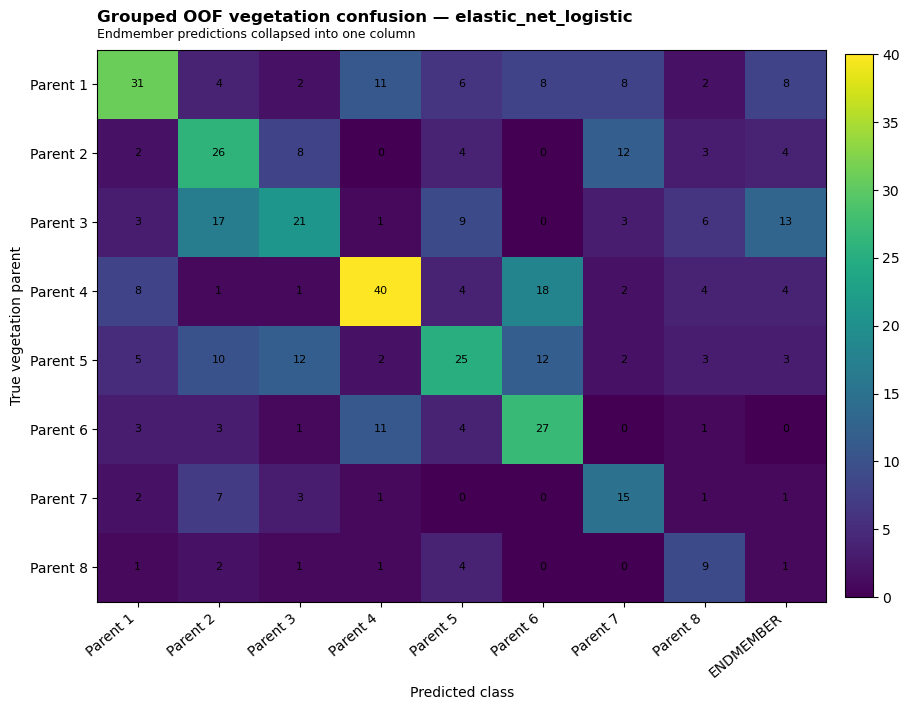

Wrote: C:\NCA_DATA\Analysis\PrelimML_Endmembers_MaskV2\ParentML_maskV2_endmembers_vegOOF_elastic_net_logistic.png


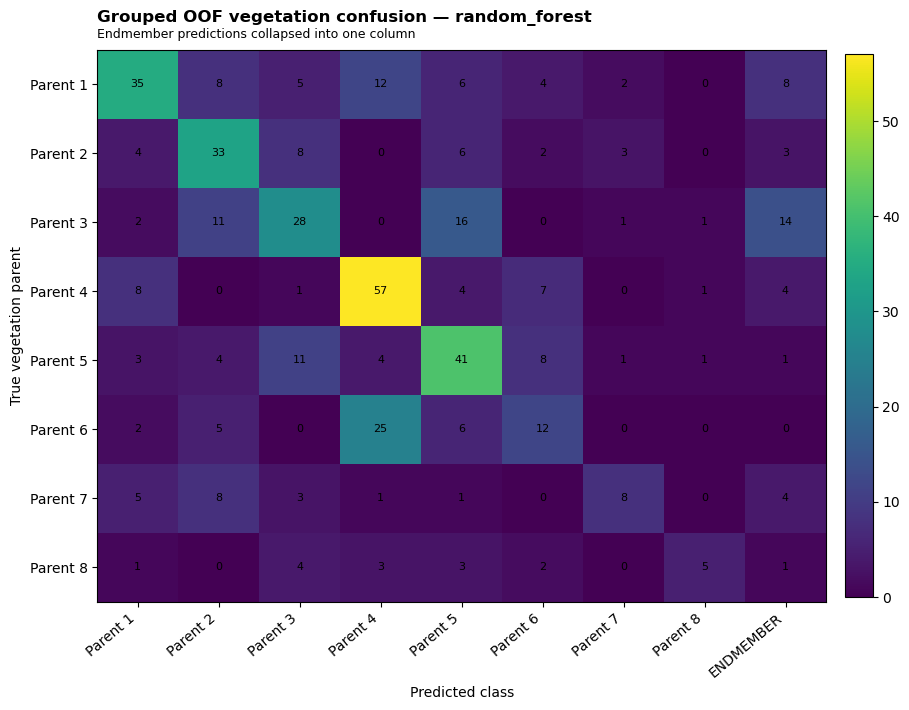

Wrote: C:\NCA_DATA\Analysis\PrelimML_Endmembers_MaskV2\ParentML_maskV2_endmembers_vegOOF_random_forest.png


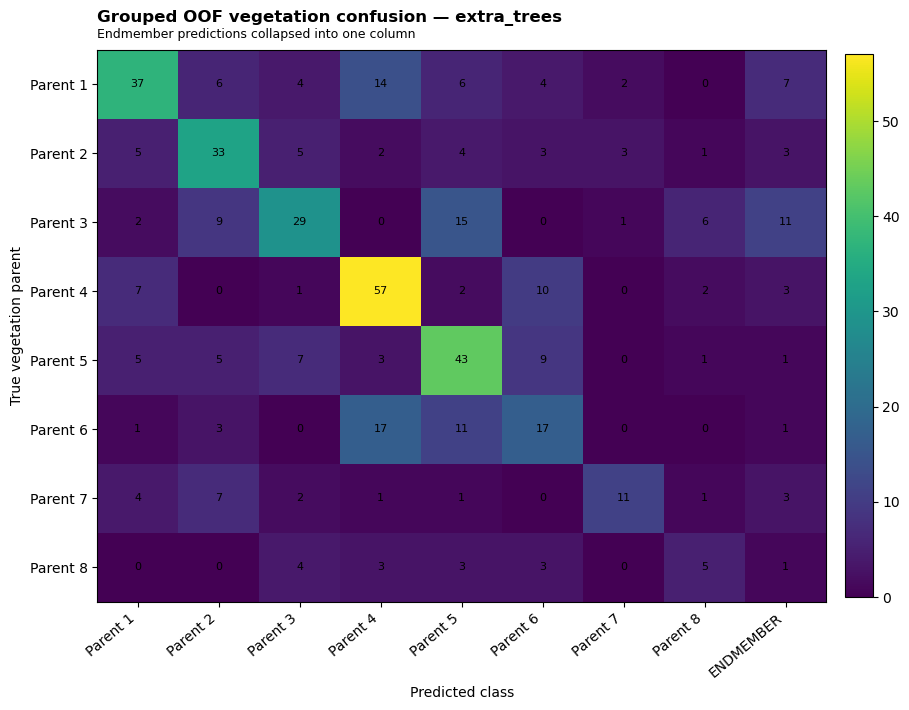

Wrote: C:\NCA_DATA\Analysis\PrelimML_Endmembers_MaskV2\ParentML_maskV2_endmembers_vegOOF_extra_trees.png


In [13]:
# =============================================================================
# VEGETATION OOF CONFUSION MATRICES
# =============================================================================

veg_true_mask = np.isin(
    y,
    VEG_CLASSES,
)

display_labels = [
    f"Parent {i}"
    for i in VEG_PARENT_CODES
] + [
    "ENDMEMBER"
]

for model_name in MODELS:

    y_true_veg = y[
        veg_true_mask
    ]

    y_pred_veg = np.asarray(
        oof[
            model_name
        ]
    )[
        veg_true_mask
    ].astype(
        str
    )

    collapsed_pred = np.where(
        np.char.startswith(
            y_pred_veg,
            "END::",
        ),
        "ENDMEMBER",
        y_pred_veg,
    )

    matrix_labels = (
        VEG_CLASSES
        + [
            "ENDMEMBER",
        ]
    )

    cm = confusion_matrix(
        y_true_veg,
        collapsed_pred,
        labels=matrix_labels,
    )

    # Remove the empty true-ENDMEMBER row, retain the prediction column.
    cm_plot = cm[
        :8,
        :
    ]

    fig, ax = plt.subplots(
        figsize=(
            9.2,
            7.2,
        )
    )

    im = ax.imshow(
        cm_plot,
        aspect="auto",
    )

    ax.set_xticks(
        np.arange(
            len(
                display_labels
            )
        )
    )

    ax.set_xticklabels(
        display_labels,
        rotation=40,
        ha="right",
    )

    ax.set_yticks(
        np.arange(
            8
        )
    )

    ax.set_yticklabels(
        [
            f"Parent {i}"
            for i in VEG_PARENT_CODES
        ]
    )

    ax.set_xlabel(
        "Predicted class"
    )

    ax.set_ylabel(
        "True vegetation parent"
    )

    ax.set_title(
        f"Grouped OOF vegetation confusion — {model_name}",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=20,
    )

    ax.text(
        0.0,
        1.015,
        "Endmember predictions collapsed into one column",
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
    )

    for i in range(
        cm_plot.shape[
            0
        ]
    ):

        for j in range(
            cm_plot.shape[
                1
            ]
        ):

            ax.text(
                j,
                i,
                int(
                    cm_plot[
                        i,
                        j,
                    ]
                ),
                ha="center",
                va="center",
                fontsize=8,
            )

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.035,
        pad=0.025,
    )

    fig.tight_layout()

    path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_vegOOF_{model_name}.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        path
    )


## 12. Leave-one-vegetation-year-out validation

For each of 2016, 2018, and 2025, all samples from that year are removed before fitting. This prevents same-year endmember support from leaking into the held-out annual domain.

Vegetation-only scores are the primary temporal-transfer comparison.


In [14]:
# =============================================================================
# LEAVE-ONE-YEAR-OUT
# =============================================================================

loyo_rows = []

years_array = combined[
    "Year"
].to_numpy(
    dtype=int
)

for model_name, template in MODELS.items():

    for held_year in VEG_YEARS:

        train_mask = (
            years_array
            != held_year
        )

        test_mask = (
            years_array
            == held_year
        )

        fitted = clone(
            template
        )

        fitted.fit(
            X[
                train_mask
            ],
            y[
                train_mask
            ],
        )

        pred = fitted.predict(
            X[
                test_mask
            ]
        ).astype(
            str
        )

        all_scores = score_label_predictions(
            y_true=y[
                test_mask
            ],
            y_pred=pred,
            labels=ALL_CLASSES,
        )

        veg_scores = score_vegetation_subset(
            y_true=y[
                test_mask
            ],
            y_pred=pred,
        )

        loyo_rows.append({
            "model": model_name,
            "held_out_year": held_year,
            "n_train": int(
                train_mask.sum()
            ),
            "n_test": int(
                test_mask.sum()
            ),
            **all_scores,
            **veg_scores,
        })


loyo_results = pd.DataFrame(
    loyo_rows
)

display(
    loyo_results.round(
        4
    )
)

loyo_results.to_csv(
    OUTPUT_DIR
    / "ParentML_maskV2_endmembers_leaveYearOut.csv",
    index=False,
)


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in

,model,held_out_year,n_train,n_test,accuracy,balanced_accuracy,macro_f1,veg_n,veg_accuracy,veg_balanced_accuracy,veg_macro_f1,veg_predicted_as_endmember_fraction
0,elastic_net_logistic,2016,1055,332,0.2229,0.2715,0.1465,244,0.1066,0.0951,0.0746,0.5533
1,elastic_net_logistic,2018,1189,198,0.3889,0.3826,0.2711,106,0.1132,0.2593,0.0724,0.1509
2,elastic_net_logistic,2025,1187,200,0.4450,0.4144,0.3097,117,0.1795,0.2624,0.1818,0.3419
3,random_forest,2016,1055,332,0.1416,0.2132,0.1214,244,0.0000,0.0000,0.0000,0.9877
4,random_forest,2018,1189,198,0.4343,0.3673,0.3138,106,0.1415,0.1779,0.1440,0.2358
5,random_forest,2025,1187,200,0.4500,0.4098,0.3451,117,0.1197,0.1509,0.1503,0.5897
6,extra_trees,2016,1055,332,0.1295,0.2338,0.1184,244,0.0000,0.0000,0.0000,0.9877
7,extra_trees,2018,1189,198,0.4343,0.4262,0.3210,106,0.1038,0.2358,0.1555,0.4245
8,extra_trees,2025,1187,200,0.4300,0.3748,0.3045,117,0.0940,0.1164,0.1134,0.6667


## 13. Controlled before/after evaluation target

For direct comparison with the previous vegetation-only baseline, focus on:

- grouped OOF vegetation accuracy
- grouped OOF vegetation balanced accuracy
- grouped OOF vegetation macro F1
- fraction of true vegetation plots now routed to an explicit endmember
- leave-year-out vegetation macro F1

Do not compare the new all-class macro F1 directly to the old eight-class macro F1 because the response space now contains additional endmember classes.


In [15]:
# =============================================================================
# COMPACT EVALUATION REPORT
# =============================================================================

print(
    "GROUPED OOF — VEGETATION-ONLY"
)

display(
    cv_summary[
        [
            "model",
            "veg_accuracy_mean",
            "veg_balanced_accuracy_mean",
            "veg_macro_f1_mean",
            "veg_to_endmember_mean",
        ]
    ].round(
        4
    )
)

print(
    "\nLEAVE-ONE-YEAR-OUT — VEGETATION-ONLY"
)

display(
    loyo_results[
        [
            "model",
            "held_out_year",
            "veg_n",
            "veg_accuracy",
            "veg_balanced_accuracy",
            "veg_macro_f1",
            "veg_predicted_as_endmember_fraction",
        ]
    ].round(
        4
    )
)


GROUPED OOF — VEGETATION-ONLY


,model,veg_accuracy_mean,veg_balanced_accuracy_mean,veg_macro_f1_mean,veg_to_endmember_mean
1,extra_trees,0.4959,0.4791,0.4703,0.0646
2,random_forest,0.4676,0.4435,0.4425,0.0753
0,elastic_net_logistic,0.4147,0.4331,0.4062,0.0731



LEAVE-ONE-YEAR-OUT — VEGETATION-ONLY


,model,held_out_year,veg_n,veg_accuracy,veg_balanced_accuracy,veg_macro_f1,veg_predicted_as_endmember_fraction
0,elastic_net_logistic,2016,244,0.1066,0.0951,0.0746,0.5533
1,elastic_net_logistic,2018,106,0.1132,0.2593,0.0724,0.1509
2,elastic_net_logistic,2025,117,0.1795,0.2624,0.1818,0.3419
3,random_forest,2016,244,0.0000,0.0000,0.0000,0.9877
4,random_forest,2018,106,0.1415,0.1779,0.1440,0.2358
5,random_forest,2025,117,0.1197,0.1509,0.1503,0.5897
6,extra_trees,2016,244,0.0000,0.0000,0.0000,0.9877
7,extra_trees,2018,106,0.1038,0.2358,0.1555,0.4245
8,extra_trees,2025,117,0.0940,0.1164,0.1134,0.6667


## 14. Fit the final random forest on all retained vegetation + endmember samples


In [16]:
# =============================================================================
# FINAL MAPPING MODEL
# =============================================================================

mapping_model = clone(
    MODELS[
        MODEL_FOR_MAPPING
    ]
)

fit_start = time.perf_counter()

mapping_model.fit(
    X,
    y,
)

fit_minutes = (
    time.perf_counter()
    - fit_start
) / 60.0

print(
    "Mapping model:",
    MODEL_FOR_MAPPING
)

print(
    "Fit time:",
    f"{fit_minutes:.2f} min"
)

print(
    "Classes in fitted model:",
    len(
        mapping_model.classes_
    )
)


Mapping model: random_forest
Fit time: 0.01 min
Classes in fitted model: 16


## 15. Raster classification helpers

The updated keep mask defines the output support.

Hard class and uncertainty are derived from the same single `predict_proba()` pass through the forest.


In [17]:
# =============================================================================
# RASTER HELPERS
# =============================================================================

def grids_match(
    src_a,
    src_b,
):

    return (
        src_a.width == src_b.width
        and src_a.height == src_b.height
        and src_a.transform == src_b.transform
        and src_a.crs == src_b.crs
    )


def predictive_entropy(
    proba,
):

    eps = 1e-12

    return -np.sum(
        proba
        * np.log(
            np.maximum(
                proba,
                eps,
            )
        ),
        axis=1,
    )


def classify_year(
    year,
    model,
):

    src_path = annual_k2_path(
        year
    )

    class_path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_RF_{year}_class.tif"
    )

    uncertainty_path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_RF_{year}_uncertainty.tif"
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"CLASSIFYING {year}"
    )

    print(
        "=" * 100
    )

    year_start = time.perf_counter()

    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        KEEP_MASK
    ) as mask_src:

        indexes = ia_band_indexes(
            src,
            IA_COLS,
        )

        use_direct_mask = grids_match(
            src,
            mask_src,
        )

        mask_vrt = None

        if use_direct_mask:

            print(
                "Mask grid matches annual raster."
            )

        else:

            print(
                "Mask grid differs; using nearest-neighbor WarpedVRT."
            )

            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )

        blocks = list(
            src.block_windows(
                1
            )
        )

        n_blocks = len(
            blocks
        )

        class_profile = src.profile.copy()

        class_profile.update(
            driver="GTiff",
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        uncertainty_profile = src.profile.copy()

        uncertainty_profile.update(
            driver="GTiff",
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        model_classes = [
            str(
                c
            )
            for c in model.classes_
        ]

        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_class_code",
            )

            uncertainty_dst.set_band_description(
                1,
                "max_probability",
            )

            uncertainty_dst.set_band_description(
                2,
                "probability_margin",
            )

            uncertainty_dst.set_band_description(
                3,
                "prediction_entropy",
            )

            total_keep = 0
            total_valid = 0

            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                if use_direct_mask:

                    keep = mask_src.read(
                        1,
                        window=window,
                        masked=False,
                    )

                else:

                    keep = mask_vrt.read(
                        1,
                        window=window,
                        masked=False,
                    )

                keep_valid = (
                    np.isfinite(
                        keep
                    )
                    & (
                        keep > 0
                    )
                )

                total_keep += int(
                    keep_valid.sum()
                )

                features = src.read(
                    indexes,
                    window=window,
                    masked=False,
                ).astype(
                    np.float32,
                    copy=False,
                )

                features = np.moveaxis(
                    features,
                    0,
                    -1,
                )

                valid = (
                    keep_valid
                    & np.isfinite(
                        features
                    ).all(
                        axis=2
                    )
                )

                if src.nodata is not None:

                    valid &= ~np.any(
                        np.isclose(
                            features,
                            src.nodata,
                        ),
                        axis=2,
                    )

                n_valid = int(
                    valid.sum()
                )

                total_valid += n_valid

                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )

                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )

                if n_valid > 0:

                    X_block = features[
                        valid
                    ]

                    raw_proba = model.predict_proba(
                        X_block
                    ).astype(
                        np.float32,
                        copy=False,
                    )

                    winner_idx = np.argmax(
                        raw_proba,
                        axis=1,
                    )

                    winner_class = np.asarray(
                        model_classes,
                        dtype=object,
                    )[
                        winner_idx
                    ]

                    winner_code = np.fromiter(
                        (
                            CLASS_TO_CODE[
                                cls
                            ]
                            for cls in winner_class
                        ),
                        dtype=np.uint8,
                        count=len(
                            winner_class
                        ),
                    )

                    class_block[
                        valid
                    ] = winner_code

                    sorted_p = np.sort(
                        raw_proba,
                        axis=1,
                    )

                    max_p = sorted_p[
                        :,
                        -1
                    ]

                    margin = (
                        sorted_p[
                            :,
                            -1
                        ]
                        - sorted_p[
                            :,
                            -2
                        ]
                    )

                    entropy = predictive_entropy(
                        raw_proba
                    )

                    uncertainty_block[
                        0
                    ][
                        valid
                    ] = max_p

                    uncertainty_block[
                        1
                    ][
                        valid
                    ] = margin

                    uncertainty_block[
                        2
                    ][
                        valid
                    ] = entropy.astype(
                        np.float32
                    )

                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )

                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == n_blocks
                ):

                    elapsed = (
                        time.perf_counter()
                        - year_start
                    )

                    rate = (
                        block_number
                        / elapsed
                        if elapsed > 0
                        else np.nan
                    )

                    remaining = (
                        n_blocks
                        - block_number
                    )

                    eta_sec = (
                        remaining
                        / rate
                        if rate > 0
                        else np.nan
                    )

                    print(
                        f"{year} | "
                        f"{block_number:,}/{n_blocks:,} "
                        f"({100 * block_number / n_blocks:5.1f}%) | "
                        f"elapsed {elapsed / 60:6.1f} min | "
                        f"ETA {eta_sec / 60:6.1f} min | "
                        f"classified {total_valid:,} px"
                    )

        if mask_vrt is not None:

            mask_vrt.close()

    runtime_minutes = (
        time.perf_counter()
        - year_start
    ) / 60.0

    print(
        f"\n{year} complete in {runtime_minutes:.1f} min"
    )

    return {
        "Year": year,
        "runtime_minutes": runtime_minutes,
        "keep_pixels": total_keep,
        "classified_pixels": total_valid,
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
    }


## 16. Classify 2016–2025


In [18]:
# =============================================================================
# ALL-YEAR MAPPING
# =============================================================================

all_start = time.perf_counter()

map_results = []

for year in YEARS_TO_MAP:

    result = classify_year(
        year=year,
        model=mapping_model,
    )

    map_results.append(
        result
    )

    pd.DataFrame(
        map_results
    ).to_csv(
        OUTPUT_DIR
        / "ParentML_maskV2_endmembers_progress.csv",
        index=False,
    )


map_results = pd.DataFrame(
    map_results
)

total_minutes = (
    time.perf_counter()
    - all_start
) / 60.0

print(
    "\nALL YEARS COMPLETE"
)

print(
    f"Total runtime: {total_minutes:.1f} min "
    f"({total_minutes / 60:.2f} hr)"
)

display(
    map_results
)

map_results.to_csv(
    OUTPUT_DIR
    / "ParentML_maskV2_endmembers_allYears_outputs.csv",
    index=False,
)



CLASSIFYING 2016
Mask grid matches annual raster.
2016 | 1/336 (  0.3%) | elapsed    0.0 min | ETA    2.3 min | classified 0 px
2016 | 25/336 (  7.4%) | elapsed    0.2 min | ETA    2.6 min | classified 314,711 px
2016 | 50/336 ( 14.9%) | elapsed    1.0 min | ETA    5.5 min | classified 2,450,378 px
2016 | 75/336 ( 22.3%) | elapsed    1.9 min | ETA    6.4 min | classified 5,037,746 px
2016 | 100/336 ( 29.8%) | elapsed    2.8 min | ETA    6.7 min | classified 7,955,406 px
2016 | 125/336 ( 37.2%) | elapsed    4.0 min | ETA    6.7 min | classified 11,332,370 px
2016 | 150/336 ( 44.6%) | elapsed    5.4 min | ETA    6.7 min | classified 15,734,469 px
2016 | 175/336 ( 52.1%) | elapsed    7.0 min | ETA    6.5 min | classified 20,715,926 px
2016 | 200/336 ( 59.5%) | elapsed    8.5 min | ETA    5.8 min | classified 25,116,693 px
2016 | 225/336 ( 67.0%) | elapsed    9.6 min | ETA    4.7 min | classified 28,318,022 px
2016 | 250/336 ( 74.4%) | elapsed   10.4 min | ETA    3.6 min | classified 30,6

KeyboardInterrupt: 

## 17. Annual mapped class frequencies


In [ ]:
# =============================================================================
# CLASS FREQUENCIES
# =============================================================================

frequency_rows = []

for year in YEARS_TO_MAP:

    path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_RF_{year}_class.tif"
    )

    with rasterio.open(
        path
    ) as src:

        arr = src.read(
            1,
            masked=False,
        )

    valid = (
        arr > 0
    )

    n_valid = int(
        valid.sum()
    )

    codes, counts = np.unique(
        arr[
            valid
        ],
        return_counts=True,
    )

    summary = pd.DataFrame({
        "Year": year,
        "class_code": codes.astype(
            int
        ),
        "n_pixels": counts.astype(
            np.int64
        ),
    })

    summary[
        "class_name"
    ] = summary[
        "class_code"
    ].map(
        CODE_TO_CLASS
    )

    summary[
        "percent"
    ] = (
        100.0
        * summary[
            "n_pixels"
        ]
        / n_valid
    )

    frequency_rows.append(
        summary
    )

    print(
        "\n",
        year
    )

    display(
        summary
    )


frequency_df = pd.concat(
    frequency_rows,
    ignore_index=True,
)

frequency_df.to_csv(
    OUTPUT_DIR
    / "ParentML_maskV2_endmembers_allYears_class_frequencies.csv",
    index=False,
)


## 18. Annual uncertainty summaries


In [ ]:
# =============================================================================
# UNCERTAINTY SUMMARIES
# =============================================================================

uncertainty_rows = []

band_names = {
    1: "max_probability",
    2: "probability_margin",
    3: "prediction_entropy",
}

for year in YEARS_TO_MAP:

    path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_RF_{year}_uncertainty.tif"
    )

    with rasterio.open(
        path
    ) as src:

        for band_no, metric in band_names.items():

            arr = src.read(
                band_no,
                masked=True,
            )

            values = arr.compressed()

            uncertainty_rows.append({
                "Year": year,
                "metric": metric,
                "n": len(
                    values
                ),
                "mean": float(
                    np.mean(
                        values
                    )
                ),
                "sd": float(
                    np.std(
                        values
                    )
                ),
                "p05": float(
                    np.quantile(
                        values,
                        0.05,
                    )
                ),
                "p25": float(
                    np.quantile(
                        values,
                        0.25,
                    )
                ),
                "median": float(
                    np.median(
                        values
                    )
                ),
                "p75": float(
                    np.quantile(
                        values,
                        0.75,
                    )
                ),
                "p95": float(
                    np.quantile(
                        values,
                        0.95,
                    )
                ),
            })


uncertainty_summary = pd.DataFrame(
    uncertainty_rows
)

display(
    uncertainty_summary.round(
        4
    )
)

uncertainty_summary.to_csv(
    OUTPUT_DIR
    / "ParentML_maskV2_endmembers_allYears_uncertainty_summary.csv",
    index=False,
)

print(
    "Maximum possible entropy with",
    len(
        ALL_CLASSES
    ),
    "classes:",
    np.log(
        len(
            ALL_CLASSES
        )
    ),
)


In [ ]:
# =============================================================================
# FINAL OOF CONFUSION MATRICES
# =============================================================================

for model_name in MODELS:

    print(
        "\n"
        + "=" * 110
    )

    print(
        f"OUT-OF-FOLD CONFUSION MATRICES — {model_name}"
    )

    print(
        "=" * 110
    )

    pred_all = np.asarray(
        oof[model_name]
    ).astype(str)

    # -------------------------------------------------------------------------
    # FULL VEGETATION + ENDMEMBER CONFUSION MATRIX
    # -------------------------------------------------------------------------

    full_cm = confusion_matrix(
        y,
        pred_all,
        labels=ALL_CLASSES,
    )

    display_lookup = (
        class_lookup
        .set_index("class_name")["display_name"]
        .to_dict()
    )

    full_labels = [
        display_lookup.get(
            cls,
            cls,
        )
        for cls in ALL_CLASSES
    ]

    full_cm_df = pd.DataFrame(
        full_cm,
        index=[
            f"True: {label}"
            for label in full_labels
        ],
        columns=[
            f"Pred: {label}"
            for label in full_labels
        ],
    )

    print(
        "\nFULL CLASS MATRIX"
    )

    display(
        full_cm_df
    )

    # -------------------------------------------------------------------------
    # VEGETATION-ONLY MATRIX
    # Collapse all endmember predictions into one column.
    # -------------------------------------------------------------------------

    veg_mask = np.isin(
        y,
        VEG_CLASSES,
    )

    y_true_veg = y[
        veg_mask
    ].astype(str)

    y_pred_veg = pred_all[
        veg_mask
    ]

    y_pred_collapsed = np.where(
        np.char.startswith(
            y_pred_veg,
            "END::",
        ),
        "ENDMEMBER",
        y_pred_veg,
    )

    veg_matrix_labels = (
        VEG_CLASSES
        + [
            "ENDMEMBER",
        ]
    )

    veg_cm = confusion_matrix(
        y_true_veg,
        y_pred_collapsed,
        labels=veg_matrix_labels,
    )

    # Last row corresponds to a nonexistent true ENDMEMBER class here.
    veg_cm = veg_cm[
        :8,
        :
    ]

    veg_cm_df = pd.DataFrame(
        veg_cm,
        index=[
            f"True Parent {i}"
            for i in VEG_PARENT_CODES
        ],
        columns=(
            [
                f"Pred Parent {i}"
                for i in VEG_PARENT_CODES
            ]
            + [
                "Pred ENDMEMBER",
            ]
        ),
    )

    print(
        "\nVEGETATION-FOCUSED MATRIX"
    )

    display(
        veg_cm_df
    )

In [ ]:
# =============================================================================
# FULL-RESOLUTION CLASSIFIED MAPS — 2016–2025
# =============================================================================

from matplotlib.colors import ListedColormap, BoundaryNorm


# -----------------------------------------------------------------------------
# CLASS LOOKUP
# -----------------------------------------------------------------------------

plot_lookup = (
    class_lookup
    .sort_values("class_code")
    .reset_index(drop=True)
)

CLASS_CODES = (
    plot_lookup["class_code"]
    .astype(int)
    .to_numpy()
)

CLASS_NAMES = (
    plot_lookup["display_name"]
    .astype(str)
    .tolist()
)

N_CLASSES = len(
    CLASS_CODES
)

print(
    "Classes to plot:",
    N_CLASSES
)

display(
    plot_lookup[
        [
            "class_code",
            "display_name",
            "class_source",
        ]
    ]
)


# -----------------------------------------------------------------------------
# FIXED CATEGORICAL PALETTE
# Same class gets same color in every year.
# -----------------------------------------------------------------------------

if N_CLASSES <= 20:

    base_cmap = plt.get_cmap(
        "tab20",
        N_CLASSES,
    )

else:

    base_cmap = plt.get_cmap(
        "gist_ncar",
        N_CLASSES,
    )


colors = [
    base_cmap(i)
    for i in range(
        N_CLASSES
    )
]

class_cmap = ListedColormap(
    colors
)

class_cmap.set_bad(
    alpha=0
)

class_norm = BoundaryNorm(
    np.arange(
        0.5,
        N_CLASSES + 1.5,
        1.0,
    ),
    N_CLASSES,
)


# -----------------------------------------------------------------------------
# PLOT EACH YEAR
# -----------------------------------------------------------------------------

for year in YEARS_TO_MAP:

    class_path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_RF_{year}_class.tif"
    )

    if not class_path.exists():

        print(
            "Missing:",
            class_path
        )

        continue

    with rasterio.open(
        class_path
    ) as src:

        arr = src.read(
            1,
            masked=False,
        )

        arr = np.ma.masked_where(
            arr == 0,
            arr,
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

        print(
            f"{year}: "
            f"{src.width:,} × {src.height:,} native pixels"
        )

    fig, ax = plt.subplots(
        figsize=(
            16,
            16,
        )
    )

    image = ax.imshow(
        arr,
        cmap=class_cmap,
        norm=class_norm,
        extent=extent,
        origin="upper",
        interpolation="none",
        rasterized=True,
    )

    ax.set_title(
        f"{year} predicted vegetation + endmember classes",
        loc="left",
        fontsize=15,
        fontweight="bold",
        pad=22,
    )

    ax.text(
        0.0,
        1.01,
        (
            "Random forest from IA45 harmonic features; "
            "NCA keep-mask v2; native 10 m classification"
        ),
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
        va="bottom",
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    ax.ticklabel_format(
        style="plain",
        axis="both",
        useOffset=False,
    )

    # -------------------------------------------------------------------------
    # DISCRETE COLORBAR
    # -------------------------------------------------------------------------

    cbar = fig.colorbar(
        image,
        ax=ax,
        orientation="vertical",
        fraction=0.03,
        pad=0.025,
        ticks=CLASS_CODES,
    )

    cbar.set_label(
        "Predicted class",
        fontsize=10,
    )

    cbar.ax.set_yticklabels(
        CLASS_NAMES
    )

    cbar.ax.tick_params(
        labelsize=8,
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.86,
        bottom=0.07,
        top=0.91,
    )

    figure_path = (
        OUTPUT_DIR
        / f"ParentML_maskV2_endmembers_RF_{year}_map_fullres.png"
    )

    fig.savefig(
        figure_path,
        dpi=400,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        figure_path
    )

    # Explicit cleanup before reading the next ~36 M-pixel raster.
    plt.close(
        fig
    )

    del arr

## Interpretation

This run should be compared against the vegetation-only baseline as a support experiment.

Key questions:

1. Which original vegetation parents lose mapped area to explicit endmember classes?
2. Does vegetation-only grouped OOF macro F1 improve?
3. Does leave-one-year-out vegetation macro F1 improve?
4. Do max probability and probability margin increase in genuinely vegetated areas?
5. Does uncertainty become spatially concentrated rather than widespread?
6. Are annual parent proportions more stable after unvegetated surfaces are given legitimate classes?

Litter remains unresolved by design and should be added as a later, separately documented class-support expansion.
